In [1]:
import sys,os
sys.path.append("../../src")
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from quspin_functions import projector_string as Pn
from quspin_functions import TFIM 
from project_imports import *
import numpy.linalg as la
from numpy import vdot 

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3777845295.py:15: RuntimeWarning: divide by zero encountered in matmul
  X= P@psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3777845295.py:15: RuntimeWarning: overflow encountered in matmul
  X= P@psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3777845295.py:15: RuntimeWarning: invalid value encountered in matmul
  X= P@psi0


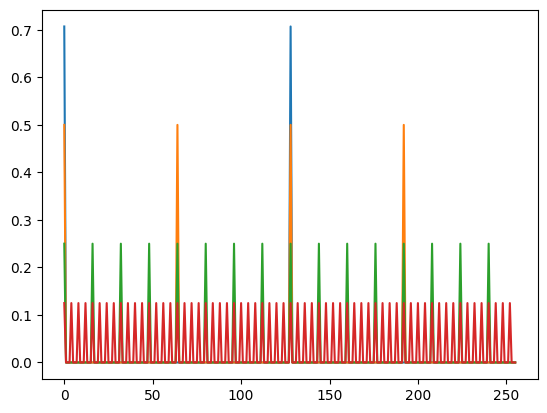

In [174]:
from quspin.operators import hamiltonian
import numpy as np

def ci_cj(i, j, basis):
    """matrix of c_i c_j in spin_basis_1d using Jordan–Wigner"""
    if i > j:
        i, j = j, i

    L = basis.L
    static = []

    # σ⁻_i σ⁻_j
    static.append(["--", [[1.0, i, j]]])

    # Jordan–Wigner string ∏_{l=i}^{j-1} σ^z_l
    for l in range(i, j):
        static.append(["z", [[1.0, l]]])

    O = hamiltonian(static, [], basis=basis, check_herm=False, check_symm=False)
    return np.array(O.todense())


def cidag_cj(i, j, basis):
    """matrix of c_i† c_j in spin_basis_1d using Jordan–Wigner"""
    if i > j:
        i, j = j, i

    L = basis.L
    static = []

    # σ⁺_i σ⁻_j
    static.append(["+-", [[1.0, i, j]]])

    # Jordan–Wigner string ∏_{l=i}^{j-1} σ^z_l
    for l in range(i, j):
        static.append(["z", [[1.0, l]]])

    O = hamiltonian(static, [], basis=basis, check_herm=False, check_symm=False)
    return np.array(O.todense())

In [200]:
import numpy as np
from quspin.operators import hamiltonian

def _op(opstr, coup, basis):
    return np.array(
        hamiltonian([[opstr, [coup]]], [], basis=basis,
                    check_herm=False, check_symm=False).todense(),
        dtype=complex
    )

def sigma_z(i, basis):
    return _op("z", [1.0, i], basis)

def sigma_p(i, basis):
    return _op("+", [1.0, i], basis)

def sigma_m(i, basis):
    return _op("-", [1.0, i], basis)

def ci(i, basis):
    O = np.eye(basis.Ns, dtype=complex)
    for l in range(i):
        O = O @ sigma_z(l, basis)
    O = O @ sigma_m(i, basis)
    return O

def cidag(i, basis):
    O = np.eye(basis.Ns, dtype=complex)
    for l in range(i):
        O = O @ sigma_z(l, basis)
    O = O @ sigma_p(i, basis)
    return O

def ck(k, basis):
    L = basis.L
    O = np.zeros((basis.Ns, basis.Ns), dtype=complex)
    for j in range(L):
        O += np.exp(-1j*k*j) * ci(j, basis)
    return O / np.sqrt(L)

def ckdag(k, basis):
    L = basis.L
    O = np.zeros((basis.Ns, basis.Ns), dtype=complex)
    for j in range(L):
        O += np.exp(+1j*k*j) * cidag(j, basis)
    return O / np.sqrt(L)

def bogoliubov_nk(k, g, basis):
    theta = np.arctan2(np.sin(k), g - np.cos(k))
    u = np.cos(theta/2)
    v = np.sin(theta/2)

    c_k = ck(k, basis)
    c_mk_dag = ckdag(-k, basis)

    gamma = u*c_k + 1j*v*c_mk_dag
    gamma_dag = gamma.conj().T
    return gamma_dag @ gamma

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3246781159.py:16: RuntimeWarning: divide by zero encountered in matmul
  X= P@psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3246781159.py:16: RuntimeWarning: overflow encountered in matmul
  X= P@psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3246781159.py:16: RuntimeWarning: invalid value encountered in matmul
  X= P@psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/2993299321.py:24: RuntimeWarning: divide by zero encountered in matmul
  O = O @ sigma_m(i, basis)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/2993299321.py:24: RuntimeWarning: overflow encountered in matmul
  O = O @ sigma_m(i, basis)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/2993299321.py:24: RuntimeWarning: invalid value encountered in matmul
  O = O @ sigma_m(i, basis)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/2993299321.py

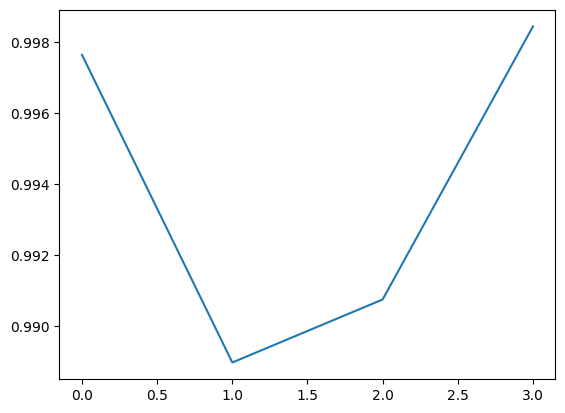

In [214]:
L = 10
g0 =8
gf=0
tau = 20
N_timestep = 400
basis = spin_basis_1d(L,pauli=-1)
#H = NonIntegrableTFIM(basis)
H = TFIM(basis)
params = dict(H0=1,g=g0)
H0 = (H.tohamiltonian(params).todense())
E0,V0 = la.eigh(H0)
psi0 = array(V0[:,0])
dat=[]
for k in ks:
    P=Pn(2,"z",basis)
    X= P@psi0
    X/= la.norm(X)
    dat.append(np.vdot(X,bogoliubov_nk(k,g0,basis)@X))

plot(dat)


In [198]:
ks = np.pi*(2*np.arange(L//2)+1)/L

In [262]:
def get_ci_sparse(i, L, basis):
    """Builds the Jordan-Wigner fermion operator c_i in the spin basis."""
    # op_str: "z" repeated i times, then "-" at position i
    op_str = "z" * i + "-"
    
    # The correct format for QuSpin is: [[coupling, site_0, site_1, ..., site_i]]
    # We need to wrap the parameters in an outer list
    indx = list(range(i + 1))
    op_list = [[1.0] + indx] 
    
    hi = hamiltonian([ [op_str, op_list] ], [], basis=basis, 
                     check_herm=False, check_symm=False, dtype=np.complex128)
    
    # Return as a sparse CSR matrix for efficiency
    return array(hi.todense())

def bogoliubov_nk_operator(L, k, g, basis):
    # 1. Pre-calculate the ci operators as sparse matrices
    # Use a list comprehension to build the local fermion operators
    cis = [get_ci_sparse(i, L, basis) for i in range(L)]
    
    # 2. Fourier Transform to get c_k
    # sum() works on sparse matrices too
    ck = sum(np.exp(-1j * k * j) * cis[j] for j in range(L)) / np.sqrt(L)
    
    # 3. Fourier Transform for c_{-k}
    # Note: k is usually defined as 2 * pi * n / L
    cmk = sum(np.exp(1j * k * j) * cis[j] for j in range(L)) / np.sqrt(L)
    cmk_dag = cmk.conj().T
    
    # 4. Bogoliubov transformation parameters
    # Standard TFIM theta calculation
    theta = np.arctan2(np.sin(k), g - np.cos(k))
    u = np.cos(theta / 2)
    v = np.sin(theta / 2)

    
    
    # 5. Construct gamma_k and n_k
    # gamma_k = u_k * c_k + i * v_k * c_{-k}^dagger
    gamma = v* ck +1j * u * cmk_dag
    gamma_dag = gamma.conj().T
    
    nk = gamma_dag @ gamma
    return nk



/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/1024766737.py:15: RuntimeWarning: divide by zero encountered in matmul
  X= P@psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/1024766737.py:15: RuntimeWarning: overflow encountered in matmul
  X= P@psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/1024766737.py:15: RuntimeWarning: invalid value encountered in matmul
  X= P@psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3686533833.py:44: RuntimeWarning: divide by zero encountered in matmul
  nk = gamma_dag @ gamma
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3686533833.py:44: RuntimeWarning: overflow encountered in matmul
  nk = gamma_dag @ gamma
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3686533833.py:44: RuntimeWarning: invalid value encountered in matmul
  nk = gamma_dag @ gamma
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/1024766737.py:16: Runt

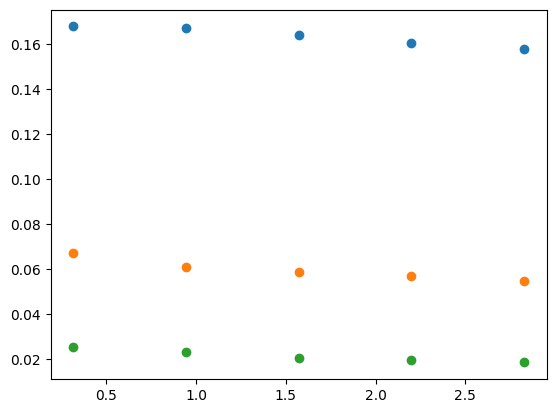

In [303]:
L = 10
g0 =2
gf=0
tau = 20
N_timestep = 400
basis = spin_basis_1d(L,pauli=-1)
ks = np.pi*(2*np.arange(L//2)+1)/L
H = TFIM(basis)
params = dict(H0=1,g=g0)
H0 = (H.tohamiltonian(params).todense())
E0,V0 = la.eigh(H0)
psi0 = array(V0[:,-1])
for n in [2,3,4]:
    P = Pn(n,"x",basis)
    X= P@psi0
    y=[np.vdot(X,bogoliubov_nk_operator(L,k,g0,basis)@X) for k in ks]
    scatter(ks,y)

In [304]:
from quspin.tools.evolution import evolve


In [305]:
taus = np.logspace(-2,2,30)

# build matrices once
H0_mat     = H.tohamiltonian(dict(H0=1, g=0)).tocsr()
Quench_mat = H.tohamiltonian(dict(H0=0, g=1)).tocsr()

def schrodinger_rhs(t, psi, H0_mat, Quench_mat, tau):
    h_t = 1 - t/tau
    return -1j * (H0_mat + h_t*Quench_mat).dot(psi)

psi_ts = []
time_lists = []
g_lists = []

for tau in taus:

    # initial Hamiltonian
    H_init = (H0_mat + g0*Quench_mat).toarray()
    E0, V0 = np.linalg.eigh(H_init)
    psi0 = V0[:,0]

    # time grid
    times = np.linspace(-tau*(g0-1), tau, N_timestep)

    psi_t = evolve(
        psi0,
        times[0],
        times,
        schrodinger_rhs,
        f_params=(H0_mat, Quench_mat, tau),
        iterate=False
    )

    gs = 1 - times/tau

    psi_ts.append(psi_t)
    time_lists.append(times)
    g_lists.append(gs)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/382223306.py:4: RuntimeWarning: divide by zero encountered in matmul
  dat.append( 1/2-np.vdot(x, P@x))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/382223306.py:4: RuntimeWarning: overflow encountered in matmul
  dat.append( 1/2-np.vdot(x, P@x))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/382223306.py:4: RuntimeWarning: invalid value encountered in matmul
  dat.append( 1/2-np.vdot(x, P@x))
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


[]

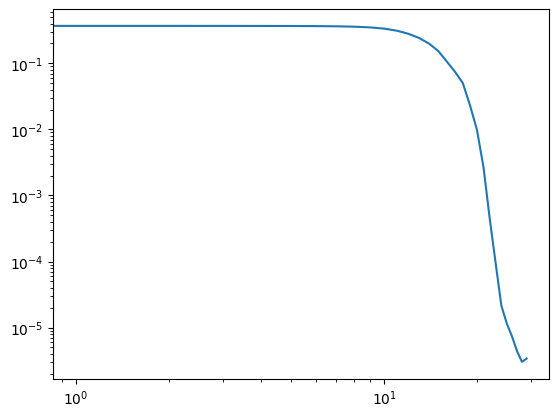

In [306]:
dat=[]
for p in psi_ts:
    x= p[:,-1]
    dat.append( 1/2-np.vdot(x, P@x))
plot(dat)
loglog()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/2221289198.py:5: RuntimeWarning: divide by zero encountered in matmul
  X= P@psi_f
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/2221289198.py:5: RuntimeWarning: overflow encountered in matmul
  X= P@psi_f
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/2221289198.py:5: RuntimeWarning: invalid value encountered in matmul
  X= P@psi_f
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3686533833.py:44: RuntimeWarning: divide by zero encountered in matmul
  nk = gamma_dag @ gamma
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3686533833.py:44: RuntimeWarning: overflow encountered in matmul
  nk = gamma_dag @ gamma
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3686533833.py:44: RuntimeWarning: invalid value encountered in matmul
  nk = gamma_dag @ gamma
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/2221289198.py:7: Runti

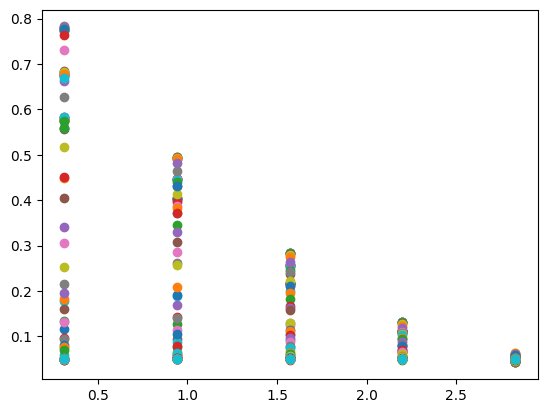

In [309]:
for p in psi_ts:
    psi_f= p[:,-1]
    for n in [2,3,4]:
        P = Pn(n,"x",basis)
        X= P@psi_f
        X = X/la.norm(X)
        y=[np.vdot(X,bogoliubov_nk_operator(L,k,0,basis)@X) for k in ks]
        scatter(ks,y)
    

In [310]:
ns = [2,3,4]
nk_data = {n: np.zeros((len(taus), len(ks))) for n in ns}

for ti, (tau, p) in enumerate(zip(taus, psi_ts)):

    psi_f = p[:,-1]

    for n in ns:

        P = Pn(n, "x", basis)
        X = P @ psi_f
        X = X / la.norm(X)

        for ki, k in enumerate(ks):
            nk_op = bogoliubov_nk_operator(L, k, 0, basis)
            nk_data[n][ti, ki] = np.vdot(X, nk_op @ X).real


for n in ns:
    figure()
    for ki, k in enumerate(ks):
        plot(taus, nk_data[n][:,ki], label=f"k={k:.2f}")
    xscale("log")
    xlabel("tau")
    ylabel(r"$\langle n_k \rangle$")
    title(f"n={n} projection")
    legend()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/4218961856.py:11: RuntimeWarning: divide by zero encountered in matmul
  X = P @ psi_f
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/4218961856.py:11: RuntimeWarning: overflow encountered in matmul
  X = P @ psi_f
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/4218961856.py:11: RuntimeWarning: invalid value encountered in matmul
  X = P @ psi_f
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3686533833.py:44: RuntimeWarning: divide by zero encountered in matmul
  nk = gamma_dag @ gamma
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3686533833.py:44: RuntimeWarning: overflow encountered in matmul
  nk = gamma_dag @ gamma
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/3686533833.py:44: RuntimeWarning: invalid value encountered in matmul
  nk = gamma_dag @ gamma
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_51303/4218961856

NameError: name 'figure' is not defined